In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=30)

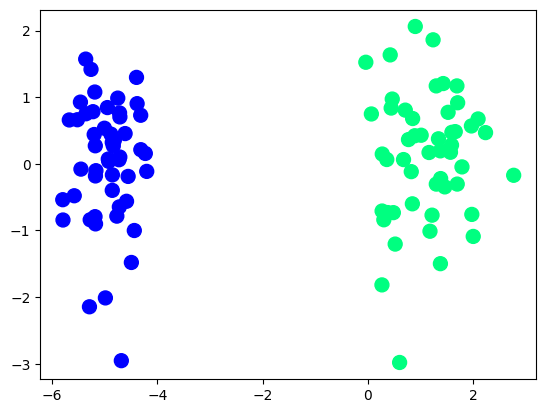

In [23]:
plt.Figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [24]:
def step(z):
    return 1 if z>0 else 0


In [25]:
def perceptron(X,y):
    X=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    lr=0.1             #Learning Rate

    for i in range(1000):
        j=np.random.randint(0,100)
        y_hat=step(np.dot(X[j],weights))
        weights=weights+lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]

In [26]:
intercept_,coef_=perceptron(X,y)



In [27]:
print(coef_)
print(intercept_)

[1.1134548  0.33857969]
1.3000000000000003


In [28]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])


In [29]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

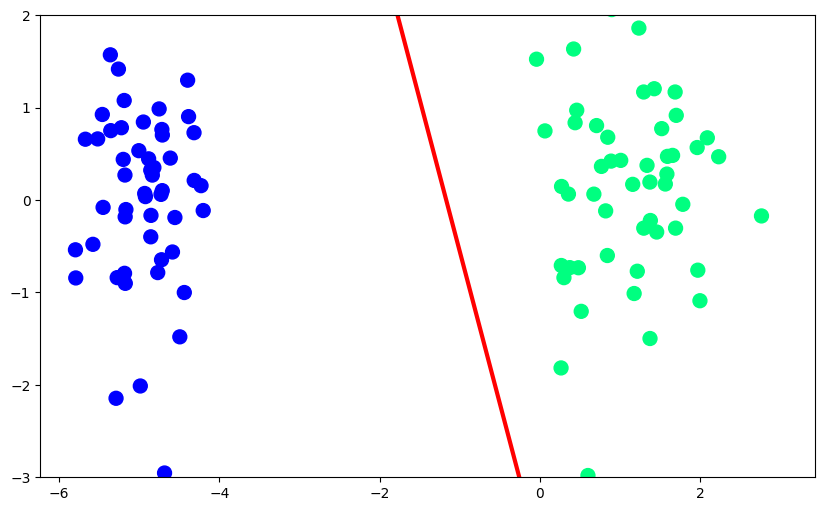

In [30]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [31]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [32]:
def perceptron(X,y):
    X=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    lr=0.1             #Learning Rate

    for i in range(1000):
        j=np.random.randint(0,100)
        y_hat=sigmoid(np.dot(X[j],weights))
        weights=weights+lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]

In [33]:
intercept_,coef_=perceptron(X,y)


In [34]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [35]:
x_input2 = np.linspace(-3,3,100)
y_input2 = m*x_input2 + b

In [36]:
from sklearn.linear_model import LogisticRegression                  #Logistic REgression is so better than perceptron trick because , perceptron stops as it completes miss classified points and ends up near that boundary or this boundary
lor = LogisticRegression()                                           # but logistic regression exactly stops at equi distance from both the boundaries
lor.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [38]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

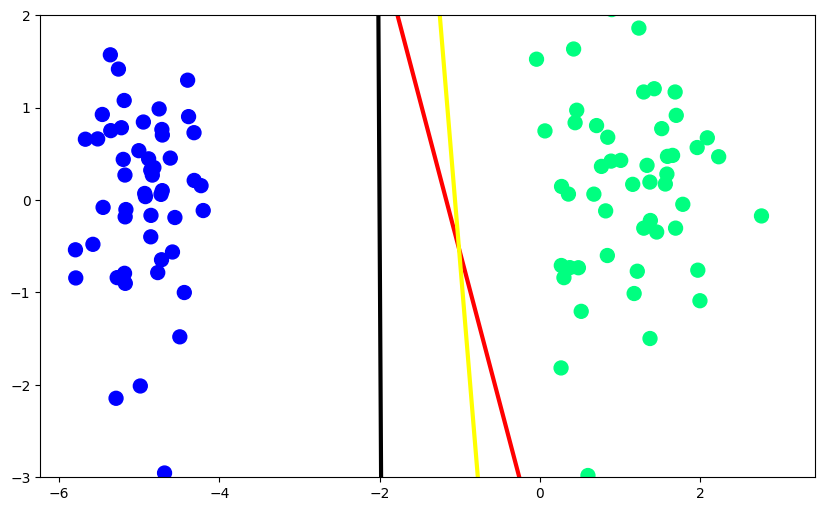

In [39]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input2,y_input2,color='yellow',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)